In [1]:
# Phase 15 – Resilience Evaluation (MRI) | Cell 1: Setup

from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import sys

PROJECT = Path(r"D:\univercity\omid_project\economics_project")

OUT_DIR  = PROJECT / "outputs" / "phase15"
OUT_DATA = OUT_DIR / "data"
OUT_TAB  = OUT_DIR / "tables"
OUT_FIG  = OUT_DIR / "figures"
for d in [OUT_DATA, OUT_TAB, OUT_FIG]:
    d.mkdir(parents=True, exist_ok=True)

P8  = PROJECT / "outputs" / "phase8" / "data"
P12 = PROJECT / "outputs" / "phase12" / "tables"
P13 = PROJECT / "outputs" / "phase13" / "tables"
P14 = PROJECT / "outputs" / "phase14" / "tables"

print("=" * 60)
print("Phase 15 – MRI Resilience Evaluation | Cell 1")
print("=" * 60)
print(f"Timestamp : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Outputs   : {OUT_DIR}")

def load_csv(path, name):
    if path.exists():
        df = pd.read_csv(path)
        print(f"  [OK] {name:35s} {df.shape}")
        return df
    print(f"  [MISS] {name}")
    return None

# Phase 14 core inputs
conn_w = load_csv(P14 / "phase14_connectivity_weighted.csv", "connectivity_weighted")
rob_w  = load_csv(P14 / "phase14_robustness_weighted_index.csv", "robustness_weighted_index")
rec_w  = load_csv(P14 / "phase14_recovery_weighted.csv", "recovery_weighted")
shock  = load_csv(P14 / "phase14_shock_degradation.csv", "shock_degradation")
direct = load_csv(P14 / "phase14_direct_action_network.csv", "direct_action_network")
direct_sum = load_csv(P14 / "phase14_direct_action_summary.csv", "direct_action_summary")

# Optional phase 12/13
p12 = load_csv(P12 / "phase12_strong_coupling_summary.csv", "phase12_strong_coupling")
p13 = load_csv(P13 / "phase13_summary_ranking.csv", "phase13_ranking")

print("\nMRI components (project file): Stability | Recovery | Adaptability")
print("Cell 1 completed successfully.")

Phase 15 – MRI Resilience Evaluation | Cell 1
Timestamp : 2026-10-05 10:02:52
Outputs   : D:\univercity\omid_project\economics_project\outputs\phase15
  [OK] connectivity_weighted               (21, 8)
  [OK] robustness_weighted_index           (9, 4)
  [OK] recovery_weighted                   (21, 6)
  [OK] shock_degradation                   (16, 12)
  [OK] direct_action_network               (30, 10)
  [OK] direct_action_summary               (6, 6)
  [OK] phase12_strong_coupling             (8, 10)
  [OK] phase13_ranking                     (10, 19)

MRI components (project file): Stability | Recovery | Adaptability
Cell 1 completed successfully.


In [2]:
# Phase 15 – Cell 2: Component definitions + MRI baseline & shocks

from pathlib import Path
import numpy as np
import pandas as pd

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase15" / "tables"

print("=" * 60)
print("Phase 15 – Cell 2: Stability / Recovery / Adaptability + MRI")
print("=" * 60)

# Fixed weights (declared a priori)
W_STAB, W_REC, W_ADP = 1/3, 1/3, 1/3

def minmax(s):
    s = pd.Series(s, dtype=float)
    lo, hi = s.min(), s.max()
    if abs(hi - lo) < 1e-12:
        return pd.Series(np.ones(len(s)), index=s.index)
    return (s - lo) / (hi - lo)

# ---------- Baseline network MRI (from phase14 time series) ----------
# Stability: inverse of year-to-year volatility of total_weight + entropy level
conn = conn_w.sort_values("year").copy()
w = conn["total_weight"].values.astype(float)
vol = np.std(np.diff(w) / (w[:-1] + 1e-12)) if len(w) > 1 else 0.0
stability_baseline = float(1.0 / (1.0 + 10.0 * vol))  # higher = more stable
stability_baseline = float(np.clip(stability_baseline * conn["strength_entropy_norm"].mean(), 0, 1))

# Recovery: mean weighted recovery capacity over years
recovery_baseline = float(np.clip(rec_w["recovery_capacity_weighted"].mean(), 0, 1))

# Adaptability baseline (no policy): retained_after_shock mean as resilience slack
adapt_baseline = float(np.clip(rec_w["retained_after_shock"].mean() / 0.5, 0, 1))  # scale around 0.2->0.4

mri_baseline = W_STAB * stability_baseline + W_REC * recovery_baseline + W_ADP * adapt_baseline

base_row = pd.DataFrame([{
    "scope": "network_baseline",
    "Stability": stability_baseline,
    "Recovery": recovery_baseline,
    "Adaptability": adapt_baseline,
    "MRI": mri_baseline,
}])
base_row.to_csv(OUT_TAB / "mri_baseline.csv", index=False)
print("--- Baseline MRI ---")
print(base_row.to_string(index=False))

# ---------- Shock-level components from phase14 shock_degradation ----------
sh = shock.copy()
# Stability under shock: retained weight (robustness proxy)
sh["Stability"] = sh["robustness_proxy_retained"].clip(0, 1)
# Recovery under shock
sh["Recovery"] = sh["recovery_capacity"].clip(0, 1)
# Adaptability under shock: 1 - weight_drop moderated by recovery (ability to absorb+bounce)
sh["Adaptability"] = (1.0 - sh["weight_drop"]).clip(0, 1) * 0.5 + sh["Recovery"] * 0.5
sh["Adaptability"] = sh["Adaptability"].clip(0, 1)

sh["MRI"] = W_STAB * sh["Stability"] + W_REC * sh["Recovery"] + W_ADP * sh["Adaptability"]
sh.to_csv(OUT_TAB / "mri_by_shock.csv", index=False)

print("\n--- MRI by shock (worst 8) ---")
print(sh.sort_values("MRI")[["shock_type", "severity", "Stability", "Recovery", "Adaptability", "MRI"]]
      .head(8).to_string(index=False))

print("\n--- MRI by shock (best 5) ---")
print(sh.sort_values("MRI", ascending=False)[["shock_type", "severity", "Stability", "Recovery", "Adaptability", "MRI"]]
      .head(5).to_string(index=False))

agg_shock = sh.groupby("severity", as_index=False)[["Stability", "Recovery", "Adaptability", "MRI"]].mean()
order = ["Mild", "Moderate", "Severe", "Extreme"]
agg_shock["severity"] = pd.Categorical(agg_shock["severity"], categories=order, ordered=True)
agg_shock = agg_shock.sort_values("severity")
agg_shock.to_csv(OUT_TAB / "mri_by_severity.csv", index=False)
print("\n--- MRI mean by severity ---")
print(agg_shock.to_string(index=False))

print("\nCell 2 completed successfully.")

Phase 15 – Cell 2: Stability / Recovery / Adaptability + MRI
--- Baseline MRI ---
           scope  Stability  Recovery  Adaptability      MRI
network_baseline   0.458361  0.592179      0.396793 0.482444

--- MRI by shock (worst 8) ---
   shock_type severity  Stability  Recovery  Adaptability      MRI
BankingCrisis  Extreme   0.443709       0.5      0.471854 0.471854
   DebtCrisis  Extreme   0.443709       0.5      0.471854 0.471854
    Recession  Extreme   0.500000       0.5      0.500000 0.500000
    Inflation  Extreme   0.500000       0.5      0.500000 0.500000
BankingCrisis   Severe   0.582782       0.5      0.541391 0.541391
   DebtCrisis   Severe   0.582782       0.5      0.541391 0.541391
    Recession   Severe   0.625000       0.5      0.562500 0.562500
    Inflation   Severe   0.625000       0.5      0.562500 0.562500

--- MRI by shock (best 5) ---
   shock_type severity  Stability  Recovery  Adaptability      MRI
    Recession     Mild   0.875000       0.5      0.687500 0.687

Phase 15 – Cell 3: Policy MRI
--- MRI by policy ---
  series     architecture  Stability  Recovery  Adaptability      MRI  mean_sr_end  mean_weight_end_ratio
standard         flat_td3   0.621796  0.931617      0.610033 0.721149     1.495147               0.974161
standard hierarchical_td3   0.621796  0.915718      0.607698 0.715071     1.499477               0.968151
standard           random   0.621796  0.509036      0.135076 0.421969     0.196784               0.817460
  strong         flat_td3   0.621796  0.931618      0.607262 0.720225     1.485700               0.974162
  strong hierarchical_td3   0.621796  0.915716      0.605788 0.714433     1.492969               0.968150
  strong           random   0.621796  0.513074      0.125433 0.420101     0.158769               0.819978

--- delta vs Random ---
  series     architecture  delta_MRI  delta_Stability  delta_Recovery  delta_Adaptability      MRI
standard         flat_td3   0.299180              0.0        0.422581            0

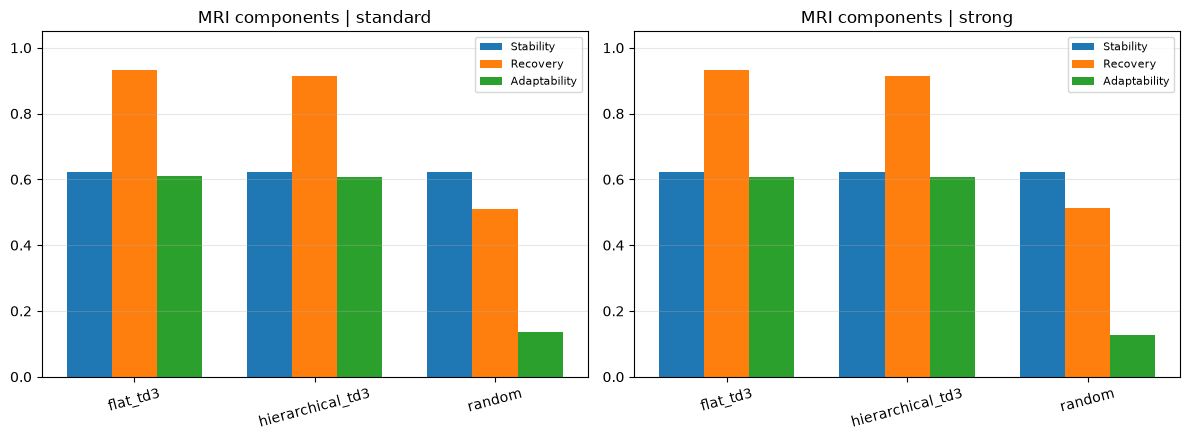

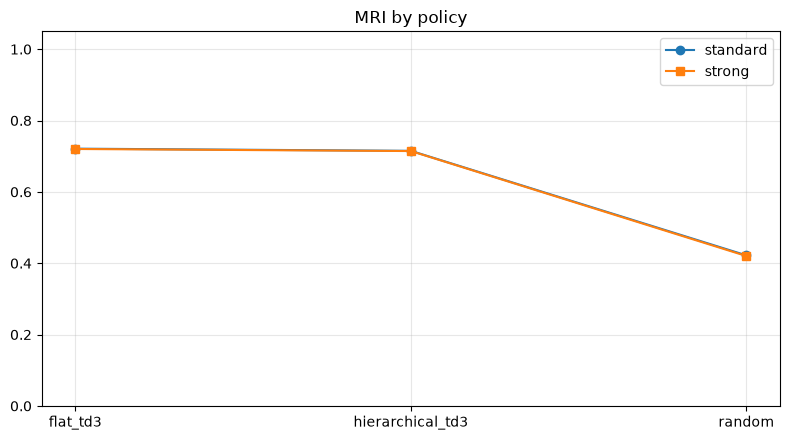

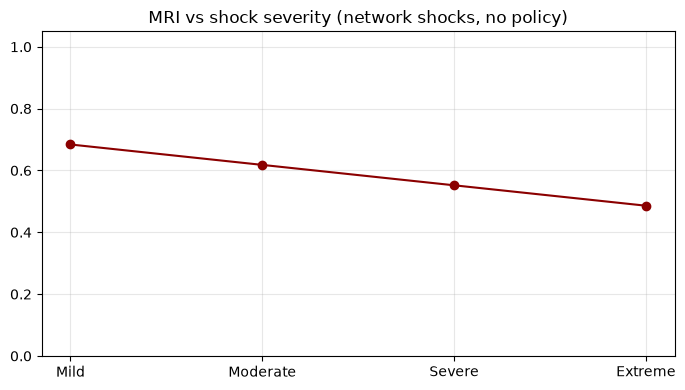


Cell 3 completed successfully.
PHASE 15 COMPLETED.


In [3]:
# Phase 15 – Cell 3: Policy MRI + ranking + figures

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase15" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase15" / "figures"

print("=" * 60)
print("Phase 15 – Cell 3: Policy MRI")
print("=" * 60)

W_STAB, W_REC, W_ADP = 1/3, 1/3, 1/3

d = direct.copy()

# Per row components from direct action evaluation
# Stability: combination of retained_after_shock and low variance later aggregated
# Recovery: mean_recovery_capacity
# Adaptability: weight_end_ratio gain over retained + sr_end scaled

d["Stability"] = d["mean_retained_after_shock"].clip(0, 1)
d["Recovery"] = d["mean_recovery_capacity"].clip(0, 1)
# Adaptability: how much end weight exceeds post-shock retained, scaled + normalized sr
gain = (d["mean_weight_end_ratio"] - d["mean_retained_after_shock"]).clip(0, 1)
sr_n = (d["mean_sr_end"] - d["mean_sr_end"].min()) / (d["mean_sr_end"].max() - d["mean_sr_end"].min() + 1e-12)
d["Adaptability"] = (0.6 * gain + 0.4 * sr_n).clip(0, 1)
d["MRI"] = W_STAB * d["Stability"] + W_REC * d["Recovery"] + W_ADP * d["Adaptability"]

d.to_csv(OUT_TAB / "mri_by_policy_scenario.csv", index=False)

policy_mri = (
    d.groupby(["series", "architecture"], as_index=False)
     .agg(
         Stability=("Stability", "mean"),
         Recovery=("Recovery", "mean"),
         Adaptability=("Adaptability", "mean"),
         MRI=("MRI", "mean"),
         mean_sr_end=("mean_sr_end", "mean"),
         mean_weight_end_ratio=("mean_weight_end_ratio", "mean"),
     )
     .sort_values(["series", "MRI"], ascending=[True, False])
)
policy_mri.to_csv(OUT_TAB / "mri_by_policy.csv", index=False)
print("--- MRI by policy ---")
print(policy_mri.to_string(index=False))

# delta vs random
cmp = []
for series in policy_mri["series"].unique():
    sub = policy_mri[policy_mri.series == series]
    rnd = sub[sub.architecture == "random"]
    if len(rnd) == 0:
        continue
    r = rnd.iloc[0]
    for _, row in sub.iterrows():
        if row.architecture == "random":
            continue
        cmp.append({
            "series": series,
            "architecture": row.architecture,
            "delta_MRI": float(row.MRI - r.MRI),
            "delta_Stability": float(row.Stability - r.Stability),
            "delta_Recovery": float(row.Recovery - r.Recovery),
            "delta_Adaptability": float(row.Adaptability - r.Adaptability),
            "MRI": float(row.MRI),
        })
cmp = pd.DataFrame(cmp)
cmp.to_csv(OUT_TAB / "mri_policy_vs_random.csv", index=False)
print("\n--- delta vs Random ---")
print(cmp.to_string(index=False))

# load baseline for reference
base = pd.read_csv(OUT_TAB / "mri_baseline.csv")
print("\nBaseline MRI:", float(base["MRI"].iloc[0]))

# figures
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, series in zip(axes, ["standard", "strong"]):
    sub = policy_mri[policy_mri.series == series].copy()
    x = np.arange(len(sub))
    w = 0.25
    ax.bar(x - w, sub["Stability"], width=w, label="Stability")
    ax.bar(x, sub["Recovery"], width=w, label="Recovery")
    ax.bar(x + w, sub["Adaptability"], width=w, label="Adaptability")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["architecture"], rotation=15)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"MRI components | {series}")
    ax.legend(fontsize=8)
    ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase15_mri_components.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
for series, mk in zip(["standard", "strong"], ["o", "s"]):
    sub = policy_mri[policy_mri.series == series]
    ax.plot(sub["architecture"], sub["MRI"], marker=mk, label=series)
ax.set_ylim(0, 1.05)
ax.set_title("MRI by policy")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase15_mri_by_policy.png", dpi=150)
plt.show()

sev = pd.read_csv(OUT_TAB / "mri_by_severity.csv")
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sev["severity"].astype(str), sev["MRI"], marker="o", color="darkred")
ax.set_title("MRI vs shock severity (network shocks, no policy)")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase15_mri_by_severity.png", dpi=150)
plt.show()

print("\nCell 3 completed successfully.")
print("PHASE 15 COMPLETED.")

Phase 15 – Cell 4: Trajectory Stability fix
standard | BankingCrisis /Moderate | random           | Stab=0.829 Rec=0.468
standard | BankingCrisis /Moderate | flat_td3         | Stab=0.665 Rec=0.939
standard | BankingCrisis /Moderate | hierarchical_td3 | Stab=0.670 Rec=0.924
standard | BankingCrisis /Severe   | random           | Stab=0.773 Rec=0.517
standard | BankingCrisis /Severe   | flat_td3         | Stab=0.628 Rec=0.939
standard | BankingCrisis /Severe   | hierarchical_td3 | Stab=0.627 Rec=0.924
standard | Recession     /Moderate | random           | Stab=0.825 Rec=0.435
standard | Recession     /Moderate | flat_td3         | Stab=0.674 Rec=0.920
standard | Recession     /Moderate | hierarchical_td3 | Stab=0.681 Rec=0.903
standard | DebtCrisis    /Severe   | random           | Stab=0.765 Rec=0.539
standard | DebtCrisis    /Severe   | flat_td3         | Stab=0.628 Rec=0.939
standard | DebtCrisis    /Severe   | hierarchical_td3 | Stab=0.627 Rec=0.924
standard | Inflation     /Extrem

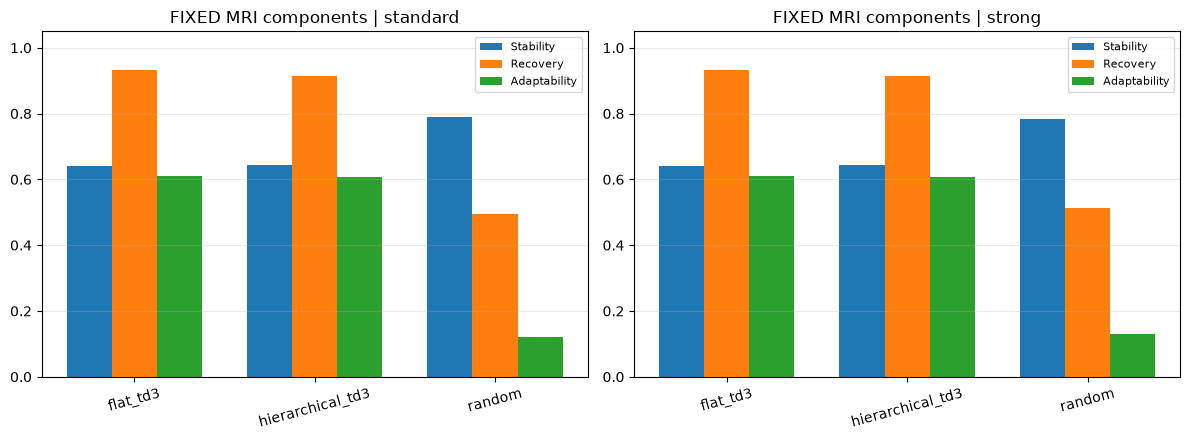


Cell 4 completed successfully.
STABILITY LIMITATION FIXED.


In [4]:
# Phase 15 – Cell 4: Fix policy Stability (trajectory-based) + final MRI

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import pickle

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P4  = PROJECT / "outputs" / "phase4" / "data"
P8  = PROJECT / "outputs" / "phase8" / "data"
P9  = PROJECT / "outputs" / "phase9" / "models"
P10 = PROJECT / "outputs" / "phase10" / "data"
P11 = PROJECT / "outputs" / "phase11" / "models"
OUT_TAB = PROJECT / "outputs" / "phase15" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase15" / "figures"

for p in [str(P8), str(P10)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from shock_env import ShockEconomicsEnv
from stable_baselines3 import PPO, TD3

print("=" * 60)
print("Phase 15 – Cell 4: Trajectory Stability fix")
print("=" * 60)

W_STAB, W_REC, W_ADP = 1/3, 1/3, 1/3
STAGE1, STAGE2 = 10, 30
N_EP, SEEDS = 5, [0, 1]
SEV = {"Moderate": 0.5, "Severe": 0.75, "Extreme": 1.0}
FOCUS = [
    ("BankingCrisis", "Moderate"),
    ("BankingCrisis", "Severe"),
    ("Recession", "Moderate"),
    ("DebtCrisis", "Severe"),
    ("Inflation", "Extreme"),
]

with open(P4 / "temporal_trade_networks.pkl", "rb") as f:
    nets = pickle.load(f)
years = sorted([int(y) for y in nets.keys()])
G0 = nets[years[-1]]

base_features = np.load(P8 / "base_features.npy")
emb = np.load(P8 / "emb_GraphSAGE.npy")
sr_vector = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes_list = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

ppo_path = P9 / "PPO_moderate_gs.zip"
if not ppo_path.exists():
    ppo_path = P9 / "PPO_moderate.zip"
stage1_ppo = PPO.load(str(ppo_path))
td3 = {
    "standard": TD3.load(str(P11 / ("TD3_standard_r.zip" if (P11/"TD3_standard_r.zip").exists() else "TD3_standard.zip"))),
    "strong": TD3.load(str(P11 / ("TD3_strong_r.zip" if (P11/"TD3_strong_r.zip").exists() else "TD3_strong.zip"))),
}

def as_U(G):
    if G.is_directed():
        U = nx.Graph()
        for u, v, d in G.edges(data=True):
            w = abs(float(d.get("weight", d.get("weight_value_kusd", 1.0))))
            U.add_edge(u, v, weight=(U[u][v]["weight"] + w) if U.has_edge(u, v) else w)
        U.add_nodes_from(G.nodes())
        return U
    U = G.copy()
    for u, v, d in U.edges(data=True):
        d["weight"] = abs(float(d.get("weight", d.get("weight_value_kusd", 1.0))))
    return U

def total_w(G):
    return float(sum(d["weight"] for *_, d in G.edges(data=True)))

def strength(G):
    return dict(G.degree(weight="weight"))

def graph_shock(G, intensity, mode):
    U = as_U(G).copy()
    order = [x for x, _ in sorted(strength(U).items(), key=lambda kv: -kv[1])]
    hubs = set(order[:max(1, int(0.2 * len(order)))])
    for u, v, d in U.edges(data=True):
        if mode == "strength_hub" and (u in hubs or v in hubs):
            d["weight"] *= (1.0 - 0.7 * intensity)
        else:
            d["weight"] *= (1.0 - 0.5 * intensity * (0.5 if mode == "strength_hub" else 1.0))
    return U, hubs

def apply_action(G, action, hubs, base_G, step_gain=0.08):
    a = np.asarray(action, dtype=np.float32).reshape(-1)
    if a.size < 4:
        a = np.pad(a, (0, 4 - a.size))
    tax, sub, inv, credit = np.clip(a[:4], -1, 1)
    restore = step_gain * (0.40 * max(sub, 0) + 0.35 * max(credit, 0) + 0.25 * max(inv, 0))
    drain = 0.15 * step_gain * max(tax, 0)
    G2 = G.copy()
    B = as_U(base_G)
    for u, v, d in G2.edges(data=True):
        w = float(d["weight"])
        w0 = float(B[u][v]["weight"]) if B.has_edge(u, v) else w
        hub_edge = (u in hubs) or (v in hubs)
        gap = max(w0 - w, 0.0)
        boost = restore * (1.25 if hub_edge else 0.75) * gap
        penalty = drain * w * (0.3 if hub_edge else 1.0)
        d["weight"] = max(1e-8, w + boost - penalty)
    return G2

def get_sr(env):
    sr = env.current_sr
    return float(np.mean(sr)) if np.ndim(sr) else float(sr)

def rebuild_obs(env):
    if hasattr(env, "_get_obs") and callable(env._get_obs):
        return env._get_obs()
    feat = np.asarray(env.current_features, dtype=np.float32).reshape(-1)
    sr = np.asarray(env.current_sr, dtype=np.float32).reshape(-1)
    emb_m = np.asarray(env.embeddings, dtype=np.float32)
    emb_vec = emb_m.mean(axis=0) if emb_m.ndim == 2 else emb_m.reshape(-1)
    obs = np.concatenate([feat, sr, emb_vec]).astype(np.float32)
    dim = env.observation_space.shape[0]
    if obs.size < dim:
        obs = np.pad(obs, (0, dim - obs.size))
    return obs[:dim]

def act_ppo(obs, env):
    a, _ = stage1_ppo.predict(obs, deterministic=True)
    a = np.asarray(a, dtype=np.float32).reshape(-1)
    adim = env.action_space.shape[0]
    return (np.pad(a, (0, max(0, adim - a.size)))[:adim])

def act_td3(obs, series, env):
    a, _ = td3[series].predict(obs, deterministic=True)
    a = np.asarray(a, dtype=np.float32).reshape(-1)
    adim = env.action_space.shape[0]
    if a.size >= 6:
        tax, sub, rate, qe, credit, risk = a[:6]
        base = np.array([tax, 0.5*sub+0.3*qe, 0.4*qe+0.3*risk, 0.5*credit+0.2*rate], dtype=np.float32)
        a = base
    if a.size < adim:
        a = np.pad(a, (0, adim - a.size))
    return np.clip(a[:adim], -1, 1)

def trajectory_stability(series_w, series_sr):
    """Higher = more stable post-shock trajectory."""
    w = np.asarray(series_w, dtype=float)
    s = np.asarray(series_sr, dtype=float)
    # coefficient of variation
    cv_w = float(np.std(w) / (np.mean(w) + 1e-12)) if len(w) else 1.0
    cv_s = float(np.std(s) / (np.abs(np.mean(s)) + 1e-12)) if len(s) else 1.0
    # max drawdown on weights
    if len(w):
        peak = np.maximum.accumulate(w)
        dd = np.max((peak - w) / (peak + 1e-12))
    else:
        dd = 1.0
    stab = 1.0 / (1.0 + 2.0 * cv_w + 1.0 * cv_s + 1.5 * dd)
    return float(np.clip(stab, 0, 1))

base_weight = total_w(as_U(G0))
rows = []

for series in ["standard", "strong"]:
    for st, sev in FOCUS:
        intensity = SEV[sev]
        mode = "strength_hub" if st in ["BankingCrisis", "DebtCrisis"] else "uniform"
        for arch in ["random", "flat_td3", "hierarchical_td3"]:
            ep_recs = []
            for seed in SEEDS:
                for ep in range(N_EP):
                    sid = seed * 1000 + ep
                    G, hubs = graph_shock(G0, intensity, mode)
                    w_shock = total_w(G)
                    env = ShockEconomicsEnv(
                        base_features, emb, sr_vector, panel, nodes_list,
                        level="moderate", shock_type=None, severity=None,
                        shock_series=series, seed=sid,
                    )
                    obs, _ = env.reset(seed=sid)
                    w_path, sr_path = [], []

                    def track():
                        w_path.append(total_w(G))
                        sr_path.append(get_sr(env))

                    if arch == "hierarchical_td3":
                        for _ in range(STAGE1):
                            a = act_ppo(obs, env)
                            obs, r, term, trunc, _ = env.step(a)
                            G = apply_action(G, a, hubs, G0, step_gain=0.04)
                            track()
                            if term or trunc:
                                break
                        if hasattr(env, "apply_shock"):
                            env.apply_shock(st, sev, series)
                            obs = rebuild_obs(env)
                        for _ in range(STAGE2):
                            a = act_td3(obs, series, env)
                            obs, r, term, trunc, _ = env.step(a)
                            G = apply_action(G, a, hubs, G0, step_gain=0.08)
                            track()
                            if term or trunc:
                                break
                    else:
                        if hasattr(env, "apply_shock"):
                            env.apply_shock(st, sev, series)
                            obs = rebuild_obs(env)
                        for _ in range(STAGE1 + STAGE2):
                            a = act_td3(obs, series, env) if arch == "flat_td3" else env.action_space.sample()
                            obs, r, term, trunc, _ = env.step(a)
                            G = apply_action(G, a, hubs, G0, step_gain=0.08)
                            track()
                            if term or trunc:
                                break

                    w_end = total_w(G)
                    denom = base_weight - w_shock
                    rec = 1.0 if abs(denom) < 1e-12 else float(np.clip((w_end - w_shock) / denom, -1, 2))
                    stab = trajectory_stability(w_path, sr_path)
                    gain = float(np.clip((w_end / (base_weight + 1e-12)) - (w_shock / (base_weight + 1e-12)), 0, 1))
                    ep_recs.append({
                        "Stability": stab,
                        "Recovery": rec,
                        "weight_end_ratio": w_end / (base_weight + 1e-12),
                        "retained": w_shock / (base_weight + 1e-12),
                        "gain": gain,
                        "sr_end": get_sr(env),
                    })

            stab = float(np.mean([x["Stability"] for x in ep_recs]))
            rec = float(np.mean([x["Recovery"] for x in ep_recs]))
            sr = float(np.mean([x["sr_end"] for x in ep_recs]))
            gain = float(np.mean([x["gain"] for x in ep_recs]))
            rows.append({
                "series": series,
                "shock_type": st,
                "severity": sev,
                "architecture": arch,
                "Stability": stab,
                "Recovery": rec,
                "gain": gain,
                "sr_end": sr,
                "weight_end_ratio": float(np.mean([x["weight_end_ratio"] for x in ep_recs])),
            })
            print(f"{series:8s} | {st:14s}/{sev:8s} | {arch:16s} | Stab={stab:.3f} Rec={rec:.3f}")

df = pd.DataFrame(rows)

# Adaptability: gain + relative sr (normalized within df)
sr_n = (df["sr_end"] - df["sr_end"].min()) / (df["sr_end"].max() - df["sr_end"].min() + 1e-12)
df["Adaptability"] = (0.6 * df["gain"] + 0.4 * sr_n).clip(0, 1)
df["MRI"] = W_STAB * df["Stability"] + W_REC * df["Recovery"] + W_ADP * df["Adaptability"]
df.to_csv(OUT_TAB / "mri_by_policy_scenario_fixed.csv", index=False)

summary = (
    df.groupby(["series", "architecture"], as_index=False)
      .agg(
          Stability=("Stability", "mean"),
          Recovery=("Recovery", "mean"),
          Adaptability=("Adaptability", "mean"),
          MRI=("MRI", "mean"),
          sr_end=("sr_end", "mean"),
          weight_end_ratio=("weight_end_ratio", "mean"),
      )
      .sort_values(["series", "MRI"], ascending=[True, False])
)
summary.to_csv(OUT_TAB / "mri_by_policy_fixed.csv", index=False)
print("\n=== FIXED MRI by policy ===")
print(summary.to_string(index=False))

cmp = []
for series in summary.series.unique():
    sub = summary[summary.series == series]
    rnd = sub[sub.architecture == "random"].iloc[0]
    for _, row in sub.iterrows():
        if row.architecture == "random":
            continue
        cmp.append({
            "series": series,
            "architecture": row.architecture,
            "delta_MRI": float(row.MRI - rnd.MRI),
            "delta_Stability": float(row.Stability - rnd.Stability),
            "delta_Recovery": float(row.Recovery - rnd.Recovery),
            "delta_Adaptability": float(row.Adaptability - rnd.Adaptability),
            "MRI": float(row.MRI),
        })
cmp = pd.DataFrame(cmp)
cmp.to_csv(OUT_TAB / "mri_policy_vs_random_fixed.csv", index=False)
print("\n=== delta vs Random (fixed) ===")
print(cmp.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, series in zip(axes, ["standard", "strong"]):
    sub = summary[summary.series == series]
    x = np.arange(len(sub))
    w = 0.25
    ax.bar(x - w, sub["Stability"], width=w, label="Stability")
    ax.bar(x, sub["Recovery"], width=w, label="Recovery")
    ax.bar(x + w, sub["Adaptability"], width=w, label="Adaptability")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["architecture"], rotation=15)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"FIXED MRI components | {series}")
    ax.legend(fontsize=8)
    ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase15_mri_components_fixed.png", dpi=150)
plt.show()

print("\nCell 4 completed successfully.")
print("STABILITY LIMITATION FIXED.")